In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("accu_fcast.csv")

In [3]:
# Add the Error columns (Day 2 requirement)
df['Error_3MA'] = df['Actual_Demand'] - df['3MA_Forecast']
df['Error_ES']  = df['Actual_Demand'] - df['ES_Forecast']

# Add APE (% Error) columns
df['APE_3MA'] = (df['Error_3MA'].abs() / df['Actual_Demand']) * 100
df['APE_ES']  = (df['Error_ES'].abs() / df['Actual_Demand']) * 100

In [4]:
#  Calculate metrics (correct ranges)
valid_3ma = df.iloc[3:12]          # Only April–Dec for 3MA

metrics = {
    "Model": ["3MA (3-month Moving Avg)", "ES (Exponential Smoothing α=0.5)"],
    "MAPE (%)": [valid_3ma['APE_3MA'].mean(), df['APE_ES'].mean()],
    "Bias": [valid_3ma['Error_3MA'].mean(), df['Error_ES'].mean()],
    "Std. Dev. of Errors": [valid_3ma['Error_3MA'].std(), df['Error_ES'].std()]
}

In [5]:
metrics_df = pd.DataFrame(metrics)

# 5. Add Recommendation (Best model)
metrics_df['Recommendation'] = [
    "Decent, but higher error",
    "**BEST MODEL** – lowest MAPE + more consistent"
]

In [9]:
# Show results
print("Here are your correct metrics:")
print(metrics_df.round(2).reset_index())

Here are your correct metrics:
   index                             Model  MAPE (%)  Bias  \
0      0          3MA (3-month Moving Avg)     22.25  3.33   
1      1  ES (Exponential Smoothing α=0.5)     15.02  4.32   

   Std. Dev. of Errors                                  Recommendation  
0                40.72                        Decent, but higher error  
1                29.78  **BEST MODEL** – lowest MAPE + more consistent  


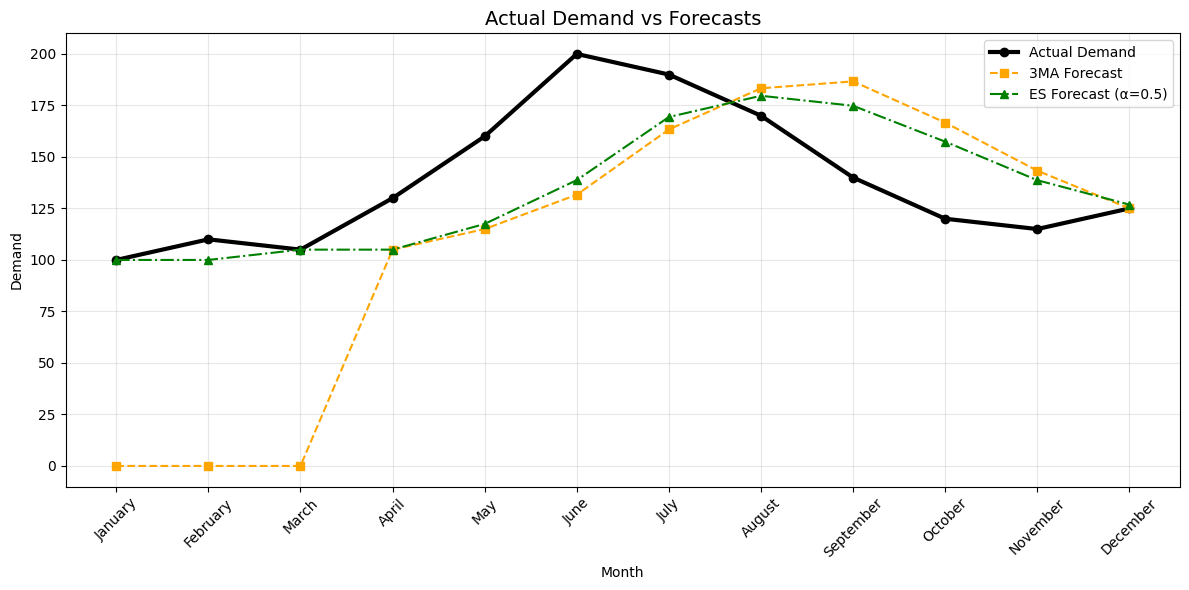

In [13]:
# ========================
# GRAPH 1: Actual vs Forecasts
# ========================
plt.figure(figsize=(12, 6))

plt.plot(df['Month'], df['Actual_Demand'], 
         label='Actual Demand', marker='o', linewidth=3, color='black')

plt.plot(df['Month'], df['3MA_Forecast'], 
         label='3MA Forecast', marker='s', linestyle='--', color='orange')

plt.plot(df['Month'], df['ES_Forecast'], 
         label='ES Forecast (α=0.5)', marker='^', linestyle='-.', color='green')

plt.title('Actual Demand vs Forecasts', fontsize=14)
plt.ylabel('Demand')
plt.xlabel('Month')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

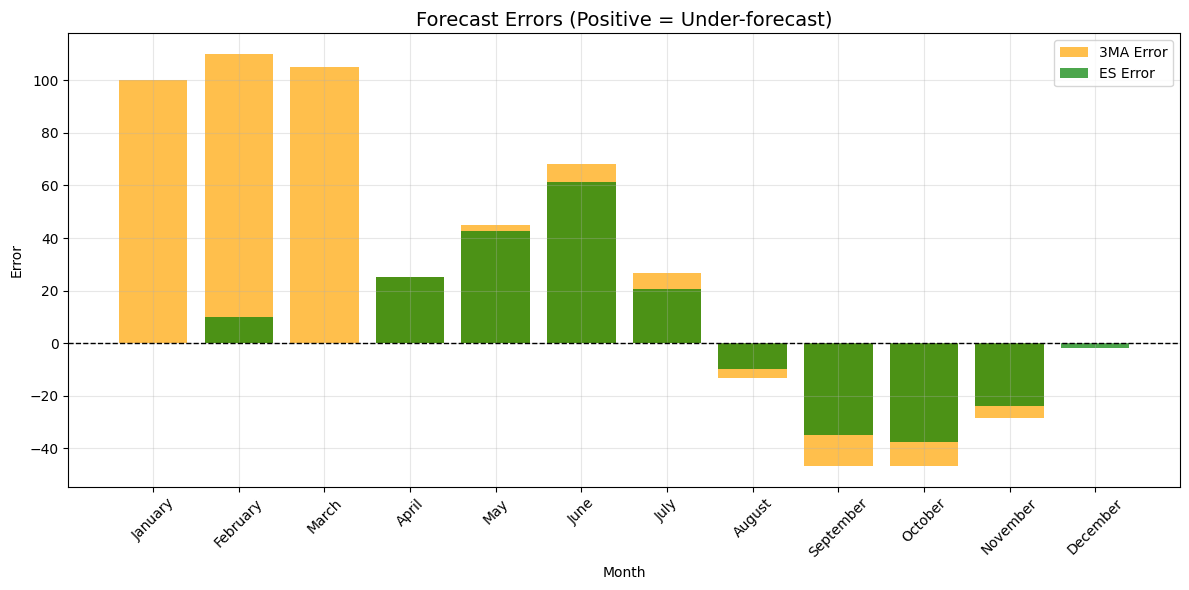

In [15]:
# ========================
# GRAPH 2: Error Analysis (shows over/under forecasting)
# ========================
plt.figure(figsize=(12, 6))

plt.bar(df['Month'], df['Error_3MA'], alpha=0.7, label='3MA Error', color='orange')
plt.bar(df['Month'], df['Error_ES'],  alpha=0.7, label='ES Error',  color='green')

plt.axhline(0, color='black', linestyle='--', linewidth=1)  # zero line
plt.title('Forecast Errors (Positive = Under-forecast)', fontsize=14)
plt.ylabel('Error')
plt.xlabel('Month')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

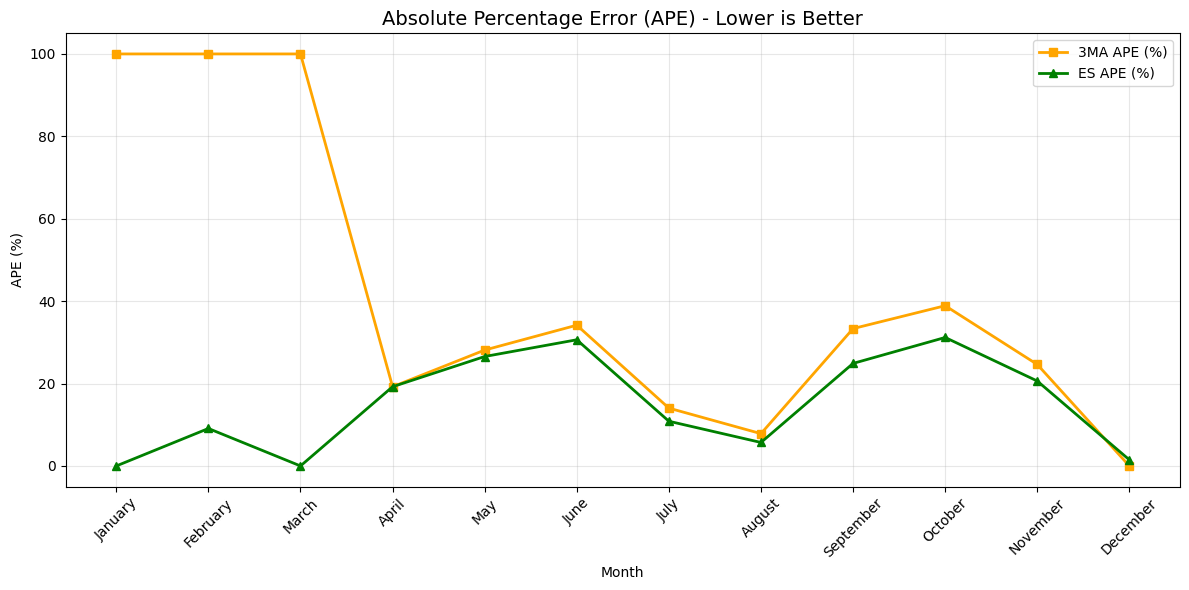

In [16]:
# ========================
# GRAPH 3: APE % Comparison
# ========================
plt.figure(figsize=(12, 6))

plt.plot(df['Month'], df['APE_3MA'], 
         label='3MA APE (%)', marker='s', color='orange', linewidth=2)

plt.plot(df['Month'], df['APE_ES'], 
         label='ES APE (%)', marker='^', color='green', linewidth=2)

plt.title('Absolute Percentage Error (APE) - Lower is Better', fontsize=14)
plt.ylabel('APE (%)')
plt.xlabel('Month')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()